<a href="https://colab.research.google.com/github/Andrespipe1/Proyecto_Analisis/blob/main/FIA_Tarea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Tamanio  Precio_venta
0     1.26         117.5
1     3.02         299.9
2     1.99         139.0
3     0.91          45.6
4     1.87         129.9
         Tamanio  Precio_venta
count  15.000000     15.000000
mean    1.883333    157.740000
std     0.609528     74.049557
min     0.910000     45.600000
25%     1.415000    105.700000
50%     1.870000    139.000000
75%     2.285000    183.450000
max     3.020000    299.900000
El error del medio cudratico es:  950.0323888236295
El coeficiente de determinación (R²)es:  0.7673971708175888
El precio estimado para una casa de 2500 pies cuadrados es: 306045.6644245975
Coeficientes:  [[122.44894476]]
Interception:  [-76.6974845]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


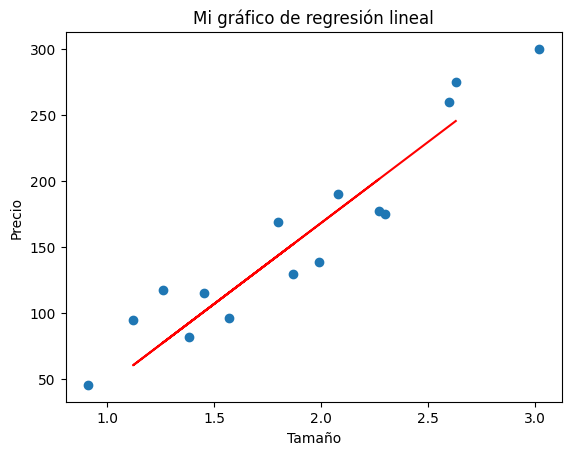

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import matplotlib.pyplot as plt

datos = pd.read_excel("WSHouse.xlsx")
print (datos.head())
print (datos.describe())

#Separar las caracteristicas
x=datos[['Tamanio']]
y=datos[['Precio_venta']]

#Dividir los datos en conjuntos de entrenamientos y prueba
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=123)

#Crear modelo (algoritmo)
modelo=LinearRegression()

#Entrenar el modelo
modelo.fit(x_train, y_train)

#Evaluar el modelo
y_proyeccion = modelo.predict(x_test)
#Metricas de evaluacion
mse=mean_squared_error(y_test,y_proyeccion)
r2=r2_score(y_test,y_proyeccion)
print("El error del medio cudratico es: ",mse)
print("El coeficiente de determinación (R²)es: ",r2)

#Grafico
plt.scatter(x,y)
plt.plot(x_test,y_proyeccion,color="red")
plt.title("Mi gráfico de regresión lineal")
plt.xlabel("Tamaño")
plt.ylabel("Precio")

#Predicciones con datos nuevos
prediccion = modelo.predict([[2500]])
print(f"El precio estimado para una casa de 2500 pies cuadrados es: {prediccion[0][0]}")

##B0 y Coeficientes
print("Coeficientes: ", modelo.coef_)
print("Interception: ", modelo.intercept_)